# PANAGEA — extracting hyperspectral Rrs (+ IOPs) as Spectrum objects

There is a premium on the **hyperspectral** Rrs observations in PANAGEA.
`pangaea.extract_hyperspectral(nband)` selects every observation whose Rrs
spectrum has more than `nband` valid wavelengths, builds an
`ocpy.spectra.Spectrum` for it, gathers any co-located IOP spectra into an
`ocpy.spectra.SpectrumStack`, and attaches scalar ancillaries (chl, TSM,
lat/lon/depth/date).

The result is a **dictionary keyed by observation `ID`**; each value is a
record of `Spectrum` / `SpectrumStack` objects, floats and ints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ocpy.insitu import pangaea
from ocpy.spectra import Spectrum, SpectrumStack

# Keep every Rrs spectrum with more than 50 wavelengths.
data = pangaea.extract_hyperspectral(nband=50)
print('hyperspectral observations:', len(data))

hyperspectral observations: 338


## Anatomy of one record

Each entry is a plain dict — easy to consume and to serialise.

In [2]:
# Pick an observation that also has spectral IOP data.
with_iop = [i for i, r in data.items() if len(r['iops']) > 0]
obs_id = with_iop[0]
rec = data[obs_id]
for k, v in rec.items():
    print(f'{k:10s}: {v!r}')

id        : 76961
rrs       : <Spectrum n=279 405.0-683.0 nm units=1/sr source=PANGAEA>
n_rrs     : 279
iops      : <SpectrumStack n=1 gridded>
iop_kinds : ['aph']
tss       : None
lat       : np.float64(42.8489)
lon       : np.float64(-11.6408)
depth     : np.float64(1322.0)
date      : np.datetime64('2008-11-07T13:12:00.000000')
chla      : 0.724


## Plot the Rrs spectrum and its companion IOP spectra

`Spectrum.plot()` handles the axes; the stack iterates its members.

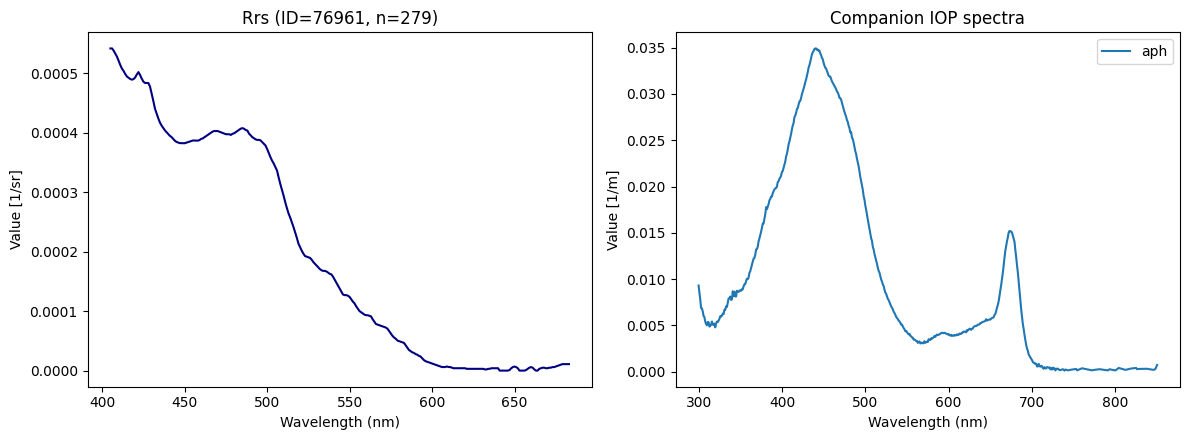

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rec['rrs'].plot(ax=axes[0], color='navy')
axes[0].set_title(f"Rrs (ID={obs_id}, n={rec['n_rrs']})")

for s in rec['iops']:
    s.plot(ax=axes[1], label=s.metadata.get('kind'))
axes[1].set_title('Companion IOP spectra')
axes[1].legend()
plt.tight_layout(); plt.show()

## What is in the collection?

Distribution of spectral richness, and how many records carry each kind of
associated IOP / ancillary.

records                : 338
  with spectral IOPs   : 3
  with TSM (tss)       : 167
  with chlorophyll     : 163
Rrs bands: min 84, median 96, max 401


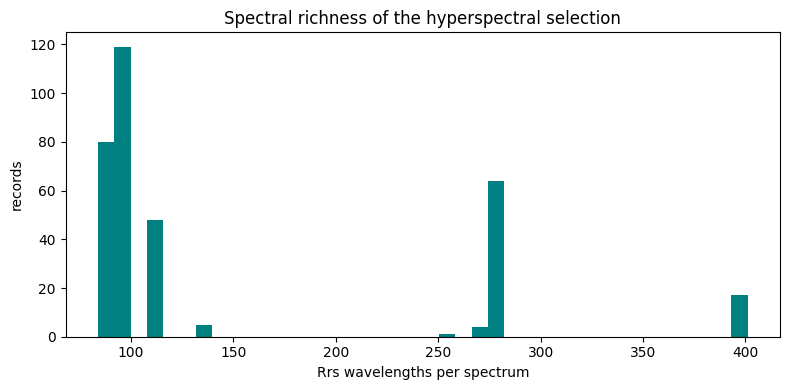

In [4]:
n_rrs = np.array([r['n_rrs'] for r in data.values()])
n_with_iop = sum(len(r['iops']) > 0 for r in data.values())
n_with_tss = sum(r['tss'] is not None for r in data.values())
n_with_chl = sum(r.get('chla') is not None for r in data.values())
print(f'records                : {len(data)}')
print(f'  with spectral IOPs   : {n_with_iop}')
print(f'  with TSM (tss)       : {n_with_tss}')
print(f'  with chlorophyll     : {n_with_chl}')
print(f'Rrs bands: min {n_rrs.min()}, median {int(np.median(n_rrs))}, '
      f'max {n_rrs.max()}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_rrs, bins=40, color='teal')
ax.set_xlabel('Rrs wavelengths per spectrum')
ax.set_ylabel('records')
ax.set_title('Spectral richness of the hyperspectral selection')
plt.tight_layout(); plt.show()

## Build a gridded stack and an Rrs "library"

Collect every Rrs `Spectrum` into a `SpectrumStack`, rebin onto a common
grid, and view the ensemble. This is the typical downstream use — a tidy,
analysis-ready matrix of hyperspectral Rrs.

ragged stack: <SpectrumStack n=338 ragged>
gridded values matrix: (338, 151)


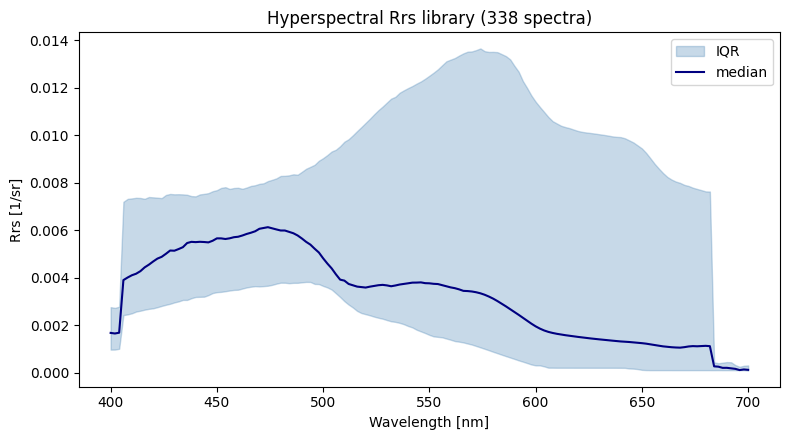

In [5]:
stack = SpectrumStack([r['rrs'] for r in data.values()])
print('ragged stack:', stack)

# Rebin onto a uniform 400-700 nm grid by interpolation.
grid = np.arange(400, 701, 2.0)
gridded = stack.rebin(grid, method='interp')
wv, vals, _ = gridded.as_array()
print('gridded values matrix:', vals.shape)

q25, q50, q75 = np.nanpercentile(vals, [25, 50, 75], axis=0)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(wv, q25, q75, alpha=0.3, color='steelblue', label='IQR')
ax.plot(wv, q50, color='navy', label='median')
ax.set_xlabel('Wavelength [nm]'); ax.set_ylabel('Rrs [1/sr]')
ax.set_title('Hyperspectral Rrs library (%d spectra)' % len(stack))
ax.legend(); plt.tight_layout(); plt.show()

## Findings & notes

* `extract_hyperspectral(nband=50)` yields **338** observations with rich
  Rrs spectra (median ~80, up to ~280 wavelengths over ~400-700 nm).
* **Co-located spectral IOPs are rare.** Although 170 of these share an
  observation `ID` with the IOP table, only **3** actually carry spectral
  IOP data (all `aph`); the remaining 167 IOP rows hold only **TSM**
  (captured as the scalar `tss`). Hyperspectral-Rrs + spectral-IOP
  match-ups are therefore the scarcest, most valuable subset of PANAGEA.
* Most records do carry a chlorophyll value, so the selection is still well
  suited to Rrs-vs-chl work even where IOPs are absent.
* Each record is a plain dict of `Spectrum` / `SpectrumStack` / float / int,
  so it drops straight into the `ocpy.spectra` tooling (rebin, `as_array`,
  netCDF I/O) for downstream analysis.